<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Project Overview </p>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">📌 <strong>What is this project about?</strong><br>In this project, I develop a contextually-aware article recommendation system leveraging Large Language Models (LLMs). Given a query article (represented only by its title and abstract), the system identifies the top 3 most relevant articles from a dataset.<br>
To ensure transparency and interpretability, I integrate SHAP (SHapley Additive exPlanations) to explain why each recommended article was selected. This allows us to pinpoint specific words or phrases in the recommended articles that influenced their ranking, improving trust and interpretability in AI-driven recommendations.<br><br>
        🔍 <strong>Methodology</strong><br>1. Data Preprocessing: The dataset consists of article titles and abstracts, which are embedded using a high-performance sentence embedding model.<br>2. Query Encoding & Similarity Matching:<br>&nbsp;&nbsp;&nbsp;&#8226;&nbsp;The input article's title and abstract are embedded.<br>&nbsp;&nbsp;&nbsp;&#8226;&nbsp;Cosine similarity is used to retrieve the top 3 most relevant articles.<br>
3. Explainability with SHAP:<br>&nbsp;&nbsp;&nbsp;&#8226;&nbsp;SHAP is applied to analyze which words or phrases contributed most to the relevance of each recommended article.<br>&nbsp;&nbsp;&nbsp;&#8226;&nbsp;This ensures interpretability and provides insights into why specific articles were suggested.

        
</p>
</div>


<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Libraries </p>

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import nltk
import math
import itertools
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer , CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler , MaxAbsScaler
from IPython.display import HTML, display

In [2]:
# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available and the code will run on", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU instead") 

GPU is available and the code will run on Tesla T4


<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Dataset Overview & Pre Processing </p>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">🧹 <strong>Cleaning The Dataset</strong><br>1. We get rid of "terms" column since we don't need it.<br>2. We delete duplicated rows and reset the indexes.<br>
3. Creating a new column that adds the title of each article to the beginning of its abstract.<br>
4. Counting the number of sentences of the new column that is named "title-abstract" and adding it as a new column to dataframe(the title counts as a sentence).
        
</p>
</div>


In [3]:
# Loading the dataframe
data = pd.read_csv("/kaggle/input/arxiv-paper-abstracts/arxiv_data_210930-054931.csv")
df = pd.DataFrame(data)
df

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...
...,...,...,...
56176,"['cs.CV', 'cs.IR']",Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...
56177,"['cs.LG', 'cs.AI', 'cs.CL', 'I.2.6; I.2.7']",Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...
56178,['cs.LG'],Deep Reinforcement Learning with Double Q-lear...,The popular Q-learning algorithm is known to o...
56179,"['stat.ML', 'cs.LG', 'math.OC']",Generalized Low Rank Models,Principal components analysis (PCA) is a well-...


In [4]:
# Deleting unnecessary column
df1 = df.drop('terms' , axis = 1)
df1

,titles,abstracts
0,Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...
...,...,...
56176,Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...
56177,Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...
56178,Deep Reinforcement Learning with Double Q-lear...,The popular Q-learning algorithm is known to o...
56179,Generalized Low Rank Models,Principal components analysis (PCA) is a well-...


In [5]:
# Deleting duplicate rows
df1 = df1.drop_duplicates(keep = 'first')
df1 = df1.reset_index(drop = True)
df1

,titles,abstracts
0,Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...
...,...,...
41115,An experimental study of graph-based semi-supe...,The volume of data generated by internet and s...
41116,Bayesian Differential Privacy through Posterio...,Differential privacy formalises privacy-preser...
41117,Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...
41118,Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...


In [6]:
# Combining title and abstracts of articles
df1['abstracts'] = df1['abstracts'].str.replace('\n', '')
title_abstract = df1['titles']+'.'+' '+df1['abstracts']
df1['title-abstract'] = title_abstract
df1

,titles,abstracts,title-abstract
0,Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,Multi-Level Attention Pooling for Graph Neural...
1,Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,Decision Forests vs. Deep Networks: Conceptual...
2,Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,Power up! Robust Graph Convolutional Network v...
3,Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...
4,Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...
...,...,...,...
41115,An experimental study of graph-based semi-supe...,The volume of data generated by internet and s...,An experimental study of graph-based semi-supe...
41116,Bayesian Differential Privacy through Posterio...,Differential privacy formalises privacy-preser...,Bayesian Differential Privacy through Posterio...
41117,Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...,Mining Spatio-temporal Data on Industrializati...
41118,Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...,Wav2Letter: an End-to-End ConvNet-based Speech...


In [7]:
# Adding the number of sentences(counting title as a single sentence) as a seperate column
sentence_count = []

for title_abstract in df1['title-abstract']:
    
    sentences = nltk.sent_tokenize(title_abstract)
    sentence_count.append(len(sentences))
df1['Sentence Count'] = sentence_count
df1

,titles,abstracts,title-abstract,Sentence Count
0,Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,Multi-Level Attention Pooling for Graph Neural...,11
1,Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,Decision Forests vs. Deep Networks: Conceptual...,12
2,Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,Power up! Robust Graph Convolutional Network v...,8
3,Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...,10
4,Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...,10
...,...,...,...,...
41115,An experimental study of graph-based semi-supe...,The volume of data generated by internet and s...,An experimental study of graph-based semi-supe...,10
41116,Bayesian Differential Privacy through Posterio...,Differential privacy formalises privacy-preser...,Bayesian Differential Privacy through Posterio...,11
41117,Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...,Mining Spatio-temporal Data on Industrializati...,8
41118,Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...,Wav2Letter: an End-to-End ConvNet-based Speech...,5


In [8]:
# An example
print(df1['title-abstract'][0])

Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities. Graph neural networks (GNNs) have been widely used to learn vectorrepresentation of graph-structured data and achieved better task performancethan conventional methods. The foundation of GNNs is the message passingprocedure, which propagates the information in a node to its neighbors. Sincethis procedure proceeds one step per layer, the range of the informationpropagation among nodes is small in the lower layers, and it expands toward thehigher layers. Therefore, a GNN model has to be deep enough to capture globalstructural information in a graph. On the other hand, it is known that deep GNNmodels suffer from performance degradation because they lose nodes' localinformation, which would be essential for good model performance, through manymessage passing steps. In this study, we propose multi-level attention pooling(MLAP) for graph-level classification tasks, which can adap

<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Exploratory Data Analysis </p>

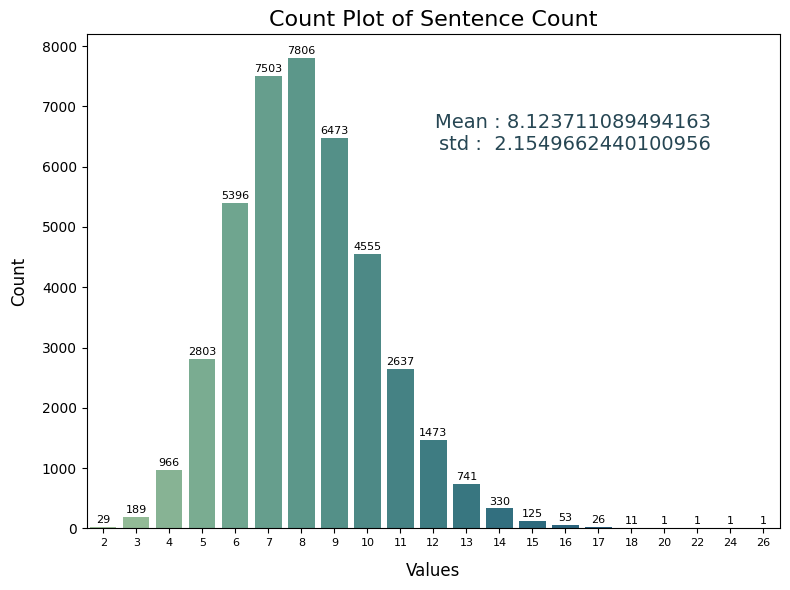

In [9]:
# Count plot for number of sentences
s = f"Mean : {df1.describe()['Sentence Count']['mean']}\nstd :  {df1.describe()['Sentence Count']['std']}"

df_count = pd.DataFrame(df1['Sentence Count'].value_counts())
df_count = df_count.sort_values(by = 'Sentence Count')

plt.figure(figsize=(8, 6))
ax = sns.barplot(x = df_count.index , y = df_count['count'], palette='crest')

# Add count annotations on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',  # The count value
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position of annotation
        ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),  # Styling
        textcoords='offset points')
    
ax.text(
    x=0.9 , y = 0.8,  # Coordinates
    s=s,  # Text to display
    fontsize=14, color='#264653', ha='right', va='center',  # Styling
    transform=ax.transAxes  # Use axes-relative positioning
)
    
plt.title('Count Plot of Sentence Count', fontsize=16)
plt.xticks(fontsize = 8)
plt.xlabel('Values', fontsize=12  , labelpad = 10)
plt.ylabel('Count', fontsize=12 , labelpad = 10)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e07a5f; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💡 This chart comes in handy when we want to use SHAP. also we can see a normal distribution and be aware of the approximate length of data that we have to process.
</p>
</div>


<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Recommendation System </p>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💭 <strong>How does this recommendation system work?</strong><br>1. Loading the bi-encoder and cross-encoder model to embed the "abstract-title" column.<br>2. Embedding the entire corpust using the bi-encoder.<br>
3. Calculating the similarity scores between the embedding of a query article and the entire corpus.<br>
4. Selecting 10 abstract with the highest score and re ranking them using cross-encoder model.<br>
5. Displaying the abstract of 3 article with the highest score after re ranking.        
</p>
</div>


<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">🔹 <strong>Bi-Encoder Model (Efficient for Retrieval)</strong><br>A Bi-Encoder independently encodes both the query and documents into fixed-length embeddings. Then, it computes similarity scores (e.g., cosine similarity) between these embeddings. Also it is fast and scalable which makes it suitable for large-scale retrieval. the only problem is that its accuracy is lower compared to cross-encoder.<br><br>
        🔹 <strong>Cross-Encoder Model (Higher Accuracy, Used for Re-Ranking)</strong><br>A Cross-Encoder processes the query and document together, rather than separately. It concatenates them and passes them through a model (like BERT) to generate a single similarity score. despite its accuracy, it is extremely slow and requires running the model for each query-document pair which is not feasible for large-scale retrieval. so instead it is used as a re-ranker.        
</p>
</div>


In [10]:
# Loading the sentence transformer and re-ranker
model = 'BAAI/bge-m3' # Bi-encoder
reranker = 'BAAI/bge-reranker-base' # Cross-encoder
model = SentenceTransformer(model)
reranker = CrossEncoder(reranker)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

In [11]:
# Adding the number of tokens as a seperate column
tokenizer = model.tokenizer
token_count = []
for text in df1['title-abstract']:
    tokens = tokenizer.encode(text, truncation=False)
    token_count.append(len(tokens))
df1['Token Count'] = token_count
df1
    
    

,titles,abstracts,title-abstract,Sentence Count,Token Count
0,Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,Multi-Level Attention Pooling for Graph Neural...,11,397
1,Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,Decision Forests vs. Deep Networks: Conceptual...,12,387
2,Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,Power up! Robust Graph Convolutional Network v...,8,209
3,Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...,10,356
4,Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...,10,339
...,...,...,...,...,...
41115,An experimental study of graph-based semi-supe...,The volume of data generated by internet and s...,An experimental study of graph-based semi-supe...,10,319
41116,Bayesian Differential Privacy through Posterio...,Differential privacy formalises privacy-preser...,Bayesian Differential Privacy through Posterio...,11,291
41117,Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...,Mining Spatio-temporal Data on Industrializati...,8,265
41118,Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...,Wav2Letter: an End-to-End ConvNet-based Speech...,5,150


In [12]:
# Optimizing the model for a speed boost
print("Default max_seq_length:", model.max_seq_length)
model.max_seq_length = max(token_count)
print("Updated max_seq_length:", model.max_seq_length)

Default max_seq_length: 8192
Updated max_seq_length: 782


<div style="border-radius:10px; padding: 15px; background-color: #e07a5f; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💡 In Large Language Models (LLMs), a token is the smallest unit of text that the model processes. Tokens can represent entire words, subwords, individual characters, or even punctuation marks, depending on how the tokenizer is designed. For example, in models like GPT, common words such as "artificial" might be a single token, while longer or less common words like "unbelievable" might be split into smaller subword tokens, such as "un" and "believable."<br>
The Model that have been used in this project, can process paragraphs with up to 8192 tokens which is way more than we need. so in order to speed up the embedding process, we change the maximum sequence length to the maximum amount of token in our own dataset.
</p>
</div>


In [13]:
# Encoding the entire corpus
corpus = model.encode(df1['title-abstract'], convert_to_tensor=True , show_progress_bar=True , device = device)

Batches:   0%|          | 0/1285 [00:00<?, ?it/s]

In [14]:
# Finding 10 articles with the most similar context for a given query
query = 0
similarity_scores = model.similarity(corpus[query], corpus)[0] # Similarity scores between the entire corpus
sorted_scores_indices = torch.argsort(similarity_scores , descending = True) # Sorting indices
similarity_scores = similarity_scores.cpu().numpy()
sorted_scores_indices = sorted_scores_indices.cpu().numpy()
top_10_indices = sorted_scores_indices[1:11] # ُSelecting top 10 article 

In [15]:
# Re-rank them using the cross encoder
pairs = [(df1['title-abstract'][query], df1['title-abstract'][i]) for i in top_10_indices] # pair of query and recommended articles
rerank_scores = reranker.predict(pairs)
sorted_rerank_scores = np.argsort(rerank_scores)[::-1] # Sorting most relevant articles

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
# Showing top 3 articles

query_title = f"""
                    <span style='font-size: 18px; font-weight: bold;'>Query Title : </span>
                    <span>&nbsp;</span>
                    <span style='background-color: #81b29a; font-size: 16px  ;'>{df1['titles'][query]}</span>"""
display(HTML(query_title))

query_abstract = f"""
                    <span style='font-size: 18px; font-weight: bold;'>Abstract : </span>
                    <span>&nbsp;</span>
                    <span style='background-color: #7678ed; color : black; font-size: 14px  ;'>{df1['abstracts'][query]}</span>"""
display(HTML(query_abstract))


for i in range(3):

    print('*'*100)
    index = top_10_indices[sorted_rerank_scores[i]]
    
    rank = f"""
                        <span style='font-size: 18px; font-weight: bold;'>Rank of Suggestion : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #3d348b; font-size: 16px; color: white;'>{i+1}</span>"""
    display(HTML(rank))

    title = f"""
                        <span style='font-size: 18px; font-weight: bold;'>Title : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #81b29a; font-size: 16px  ;'>{df1['titles'][index]}</span>"""
    display(HTML(title))

    abstract = f"""
                        <span style='font-size: 16px; font-weight: bold;'>Abstract : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #7678ed; color : black; font-size: 14px  ;'>{df1['abstracts'][index]}</span>"""
    display(HTML(abstract))


    original_score = f"""
                        <span style='font-size: 16px; font-weight: bold;'>Original Similarity Score : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #778da9; font-size: 14px  ;'>{similarity_scores[index]}</span>"""
    display(HTML(original_score))

    rerank_score = f"""
                        <span style='font-size: 16px; font-weight: bold;'>Re-rank Similarity Score : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #778da9; font-size: 14px  ;'>{rerank_scores[sorted_rerank_scores[i]]}</span>"""
    display(HTML(rerank_score))

    indice = f"""
                        <span style='font-size: 16px; font-weight: bold;'>index : </span>
                        <span>&nbsp;</span>
                        <span style='background-color: #778da9; font-size: 14px  ;'>{index}</span>"""
    display(HTML(indice))



****************************************************************************************************


****************************************************************************************************


****************************************************************************************************


<a id="3"></a>
# <p style="padding:20px;background-color:#335c67 ;margin:0;color:#f2e9e4;font-family: 'Times New Roman';font-size:90%;text-align:center;border-radius: 15px 80px;overflow:hidden;font-weight:100 ; border: 2px solid #fefae0; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Explainable AI(SHAP) </p>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">🤖 <strong>What is Explainable AI?</strong><br>Explainable AI (XAI) refers to techniques and methods that make artificial intelligence models' decisions understandable to humans. Traditional AI models, especially deep learning-based systems, often function as "black boxes," meaning their decision-making processes are complex and difficult to interpret. XAI aims to bridge this gap by providing insights into how models make predictions, ensuring transparency, trust, and fairness.<br><br>
        Techniques for explainability include feature importance analysis, visualization methods, and algorithms like SHAP (Shapley Additive Explanations) and LIME (Local Interpretable Model-agnostic Explanations), which highlight the key factors influencing a model’s decision. This is particularly important in high-stakes applications such as healthcare, finance, and legal systems, where understanding AI decisions is crucial for accountability and ethical considerations. By improving interpretability, XAI helps users trust AI models, identify biases, and refine models for better decision-making.   
</p>
</div>
<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💭 <strong>How does shap work?</strong><br>SHAP (SHapley Additive Explanations) is a powerful method for explaining machine learning model predictions by assigning importance scores to each feature. It is based on Shapley values, a concept from cooperative game theory, which fairly distributes credit among contributors (features) based on their impact on the model’s output.<br><br>
        SHAP works by computing the contribution of each feature to a model’s prediction by analyzing different subsets of features. It does this by comparing the model’s output when a specific feature is included versus when it is excluded. By averaging these contributions over all possible feature combinations, SHAP determines how much each feature increases or decreases the prediction.     
</p>
</div>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">🔍 <strong>Problem of SHAP in this project?</strong><br>Now as it is mentioned above, in order to calculate SHAPley values, we need the all the different combination of our features. in this project, the features are sentences. for a 5 sentence abstract, we need to calculate the similarity score of 15 different subset(2^5 -1) with the query to undrestand how each sentence contributes to the final result. but for a 15 or 20 sentence abstract this number would be very large and calculating every similarity score would be very time consuming.   
</p>
</div>

<div style="border-radius:10px; padding: 15px; background-color: #fff3b0; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">🧠 <strong>How SHAP Kernel solve this problem?</strong><br>The SHAP Kernel Explainer is a model-agnostic method that approximates SHAP values using a simplified version of the model. Since calculating exact Shapley values is computationally expensive, Kernel SHAP estimates them efficiently by sampling different subsets of features and observing how the model’s predictions change.<br>By selecting a subset of features, you reduce complexity while still capturing the most important factors influencing recommendations. Instead of computing SHAP values for all possible feature combinations, the Kernel Explainer samples various feature subsets and assigns weights to each based on their probability of occurrence. These weights help approximate how much each feature contributes to the model’s decision, ensuring a balance between accuracy and efficiency.<br>This approach is particularly useful in this recommendation system, where the abstract and title of articles are used as inputs. By applying weighted SHAP values, it will highlight which sentences in the recommended articles played the biggest role in their selection, making the recommendation process more transparent and interpretable.   
</p>
</div>




In [17]:
def weight_calc(m,s): # A function to calculate SHAP weights
    if m==s :
        return 0
    
    binom_coeff = math.comb(m, s)
    return (m-1)/(binom_coeff*s*(m-s))

<div style="border-radius:10px; padding: 15px; background-color: #e07a5f; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💡 There is no exact rules on how you should sample your dataset. so in this project based on the EDA and preserving the contextual meaning of the abstracts, we sample all the possible combination in a window of 8 or less sentences. for example if the abstract has 5 sentence, we sample every possible combination, but if it has 10 sentence we sample every possible combination between sentence 1 to 8, 2 to 9 and 3 to 10 and after that we delet the duplicated samples.
</p>
</div>


In [18]:
# Creating SHAP Dataframe

recommend = 14342 # The index of recommended article
no_sentences = df1['Sentence Count'][recommend] # Number of sentences in the recommended article's abstract

shap_sentences = nltk.sent_tokenize(df1['title-abstract'][recommend]) 
query_sentences = nltk.sent_tokenize(df1['title-abstract'][query])

if no_sentences<=8:
    
    # Creating the raw dataframe
    sentences = ['Sentence '+str(i+1) for i in range(no_sentences)]
    sentences.append('Weight')
    sentences.append('Y')
    shap = []
    df_shap = pd.DataFrame(columns = sentences)
    
    base = [i for i in range(no_sentences)] # A list of numbers for each sentence
    
    # Generate all combinations
    result = []
    for r in range(1,no_sentences+1):
        result.extend(itertools.combinations(base,r))

    # Creating SHAP dataframe
    for comb in result:
        
        shap_query = '' # The sentence of the current combination
        sentences = [0 for e in range(no_sentences)] # a list that indicates whether a sentence is present or absent
        for j in comb:
            sentences[j] = 1
            shap_query = shap_query+shap_sentences[j]+' '
        
        s = len(comb)
        weight = weight_calc(no_sentences,s) # Weight of the sentence in SHAP 
        sentences.append(weight)

        shap_encode = model.encode(shap_query, convert_to_tensor=True , show_progress_bar=False , device = device)
        shap_value =  model.similarity(shap_encode, corpus[query])[0][0].cpu().numpy() # Similarity score between combination and query
        sentences.append(shap_value)
        
        df_shap.loc[len(df_shap)] = sentences # Adding the new row o SHAP dataframe


if no_sentences>8: 

    # Creating the raw dataframe
    sentences = ['Sentence '+str(i+1) for i in range(no_sentences)]
    sentences.append('Weight')
    sentences.append('Y')
    shap = []
    df_shap = pd.DataFrame(columns = sentences)

    result = []
    counter = 8
    while counter<=no_sentences:
        
        # Generate all combinations
        base = [i for i in range(counter-8,counter)] # A list of numbers for each sentence
        
        for r in range(1,9): # Generating all possible combination between 1 to 8 sentence
            result.extend(itertools.combinations(base,r))

        # Creating SHAP dataframe
        for comb in result:
            
            shap_query = '' # The sentence of the current combination
            sentences = [0 for e in range(no_sentences)] # a list that indicates whether a sentence is present or absent
            for j in comb:
                sentences[j] = 1
                shap_query = shap_query+shap_sentences[j]+' '
            
            s = len(comb) # number of sentences in the combination
            weight = weight_calc(no_sentences,s) # Weight of the sentence in SHAP 
            sentences.append(weight)
            
            shap_encode = model.encode(shap_query, convert_to_tensor=True , show_progress_bar=False , device = device)
            shap_value =  model.similarity(shap_encode, corpus[query])[0].cpu().numpy() # Similarity score between combination and query
            sentences.append(shap_value[0])
            
            df_shap.loc[len(df_shap)] = sentences # Adding the new row o SHAP dataframe
        counter+=1

    df_shap = df_shap.drop_duplicates(keep = 'first')
    df_shap = df_shap.reset_index(drop = True)


    # For combinations with more than 8 sentences
    counter = 9
    while counter<no_sentences:
        
        temp_counter = counter
        while temp_counter<=no_sentences:
            sentences = [0 for e in range(no_sentences)]
            result = [i for i in range(temp_counter-counter,temp_counter)]
            shap_query = ''
            for j in result :
                sentences[j] = 1
                shap_query = shap_query+shap_sentences[j]+' '
                
            s = len(result)
            weight = weight_calc(no_sentences,s)
            sentences.append(weight)
            shap_encode = model.encode(shap_query, convert_to_tensor=True , show_progress_bar=False , device = device)
            shap_value =  model.similarity(shap_encode, corpus[query])[0].cpu().numpy()
            sentences.append(shap_value[0])


            df_shap.loc[len(df_shap)] = sentences
            temp_counter+=1
        counter+=1

df_shap   

,Sentence 1,Sentence 2,Sentence 3,Sentence 4,Sentence 5,Sentence 6,Sentence 7,Weight,Y
0,1,0,0,0,0,0,0,0.142857,0.69277763
1,0,1,0,0,0,0,0,0.142857,0.66228354
2,0,0,1,0,0,0,0,0.142857,0.4746546
3,0,0,0,1,0,0,0,0.142857,0.5792812
4,0,0,0,0,1,0,0,0.142857,0.63700926
...,...,...,...,...,...,...,...,...,...
122,1,1,1,0,1,1,1,0.142857,0.7748541
123,1,1,0,1,1,1,1,0.142857,0.78958344
124,1,0,1,1,1,1,1,0.142857,0.7462726
125,0,1,1,1,1,1,1,0.142857,0.75336254


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


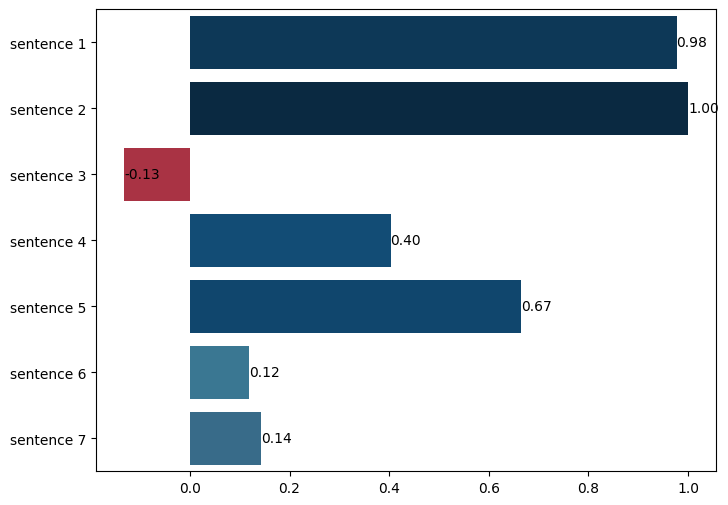


**************************************************



In [19]:
# Linear regression for the SHAP dataframe
X = df_shap.iloc[:,:no_sentences]
weights = df_shap['Weight']
Y = df_shap['Y']
reg_model = LinearRegression()
reg_model.fit(X , Y , sample_weight=weights) # Fitting the model

coef = reg_model.coef_ # Coefficients of each sentence

scaler = MaxAbsScaler() # Normalizing the coefficients in the range of 1 to 10
new_coef = scaler.fit_transform(coef.reshape(-1 , 1))
new_coef = new_coef.flatten()

sentences = ['sentence '+str(j+1) for j in range(no_sentences)]


coef_sort = new_coef.argsort()[::-1]
blue = ['#012A4A' , '#013A63' , '#01497C' , '#014F86' , '#2A6F97' , '#2C7DA0' , '#468FAF' , '#61A5C2' , '#89C2D9' , '#89C2D9']

red = ['#641220' , '#6E1423' , '#85182A', '#A11D33', '#A71E34', '#B21E35', '#BD1F36', '#C71F37', '#DA1E37', '#E01E37']
colors = []
for i in range(no_sentences) :

    index = np.where(i == coef_sort)[0][0]
    
    if coef[i] < 0 :
        if index>9 :
            colors.append(red[9])
        if index<=9 :
            colors.append(red[index])
            
    if coef[i] > 0 :
        if index>9 :
            colors.append(blue[9])
        if index<=9 :
            colors.append(blue[index])
            
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=new_coef , y=sentences , palette = colors)
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}',  # The bar value
        (p.get_width(), p.get_y() + p.get_height() / 2.),  # Position of the annotation
        ha='left', va='center', fontsize=10, color='black', xytext=(0, 0),  # Styling and offset
        textcoords='offset points')

plt.show()

sentences = []
for n , i in enumerate(shap_sentences) :
    
    sentence = f"""<span style='background-color: {colors[n]}; color : white; font-size: 14px  ;' title='Importance: {new_coef[n]}'>{i}</span>"""
    sentences.append(sentence)
shap_query =  "".join(sentences)

display(HTML(shap_query))
print('\n'+('*'*50)+'\n')
display(HTML(df1['title-abstract'][query]))

<div style="border-radius:10px; padding: 15px; background-color: #e07a5f; font-size:100%; text-align:left">
    <p style="color:#0d1b2a;">💡 Here we can see that SHAP values for the most relevant article to the query. sentence 1(the title) and sentence 2 have the most impact on the final result, while sentence 3 has a negative impact. now with this explainable recommendation system, in addition to finding the most relevant content, we can explain to user why we taught it was contextually relevant.
</p>
</div>
